# Parte 2: Análise dos Dados e Visualização Territorial
Este notebook contempla a análise exploratória avançada exigida no trabalho. 
Focaremos na criação de painéis de informações, mapas territoriais e no estudo das correlações 
entre os fatores que influenciam o valor bruto da Agropecuária.

In [1]:
import sys
from pathlib import Path

# Adicionar o diretório raiz do projeto ao path para importar config
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px  # Excelente para os mapas e painéis interativos solicitados
from config import PIB_MUNICIPIOS_PROCESSED

# Configurações de exibição
%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

# Carregando os dados limpos da Parte 1
df = pd.read_csv(PIB_MUNICIPIOS_PROCESSED)
print(f"Dados carregados com sucesso: {df.shape[0]} registros.")

Dados carregados com sucesso: 66825 registros.


## 1. Painéis de Informações (Retrato Fiel do Período)
Desenvolvemos análises para entender a distribuição do PIB Agropecuário por região e ao longo do tempo.

C:\Users\user\AppData\Local\Temp\ipykernel_1724\3010453585.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x=col_agro, y='Nome do Município', palette='viridis')


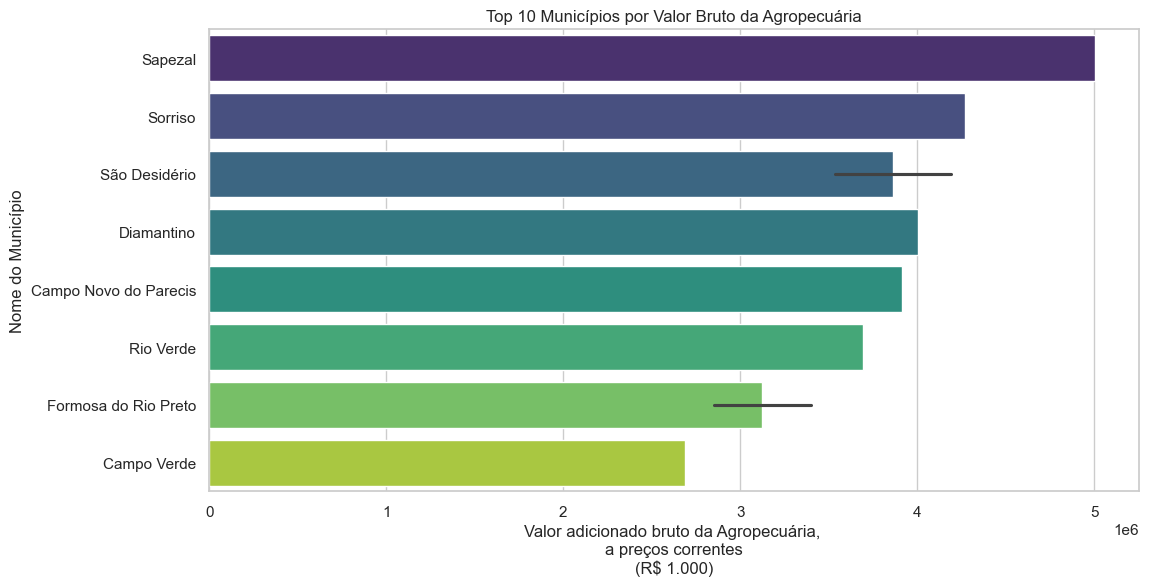

In [2]:
# Exemplo: Top 10 Municípios por Valor da Agropecuária
col_agro = 'Valor adicionado bruto da Agropecuária, \na preços correntes\n(R$ 1.000)'
top_10 = df.nlargest(10, col_agro)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_10, x=col_agro, y='Nome do Município', palette='viridis')
plt.title('Top 10 Municípios por Valor Bruto da Agropecuária')
plt.show()

## 2. Mapas com Análise Territorial
O trabalho solicita mapas territoriais. Utilizaremos o Plotly para criar um mapa de calor 
por Unidade da Federação (UF) para visualizar a concentração da produção.

In [3]:
# Agrupando por UF para o mapa
df_uf = df.groupby('Sigla da Unidade da Federação')[col_agro].sum().reset_index()
df_uf.columns = ['state', 'value']

# Criar mapa usando uma abordagem que funciona com Brasil
# Usando código ISO para estados brasileiros
state_code_map = {
    'AC': 'Acre', 'AL': 'Alagoas', 'AP': 'Amapá', 'AM': 'Amazonas',
    'BA': 'Bahia', 'CE': 'Ceará', 'DF': 'Distrito Federal', 'ES': 'Espírito Santo',
    'GO': 'Goiás', 'MA': 'Maranhão', 'MT': 'Mato Grosso', 'MS': 'Mato Grosso do Sul',
    'MG': 'Minas Gerais', 'PA': 'Pará', 'PB': 'Paraíba', 'PR': 'Paraná',
    'PE': 'Pernambuco', 'PI': 'Piauí', 'RJ': 'Rio de Janeiro', 'RN': 'Rio Grande do Norte',
    'RS': 'Rio Grande do Sul', 'RO': 'Rondônia', 'RR': 'Roraima', 'SC': 'Santa Catarina',
    'SP': 'São Paulo', 'SE': 'Sergipe', 'TO': 'Tocantins'
}

df_uf['state_name'] = df_uf['state'].map(state_code_map)

# Criar gráfico de barras como alternativa ao choropleth (mais confiável)
fig = px.bar(df_uf.sort_values('value', ascending=True), 
             y='state_name', 
             x='value',
             orientation='h',
             title='Distribuição Territorial do Valor da Agropecuária por UF',
             labels={'value': 'Valor (R$ 1.000)', 'state_name': 'Estado'},
             color='value',
             color_continuous_scale='Viridis')
fig.show()

## 3. Análise de Correlação e Associação
Conforme solicitado, analisaremos:
1. Correlação entre variáveis quantitativas (ex: Agropecuária vs Indústria).
2. Relação entre quantitativa vs qualitativa (ex: Agropecuária por Região).

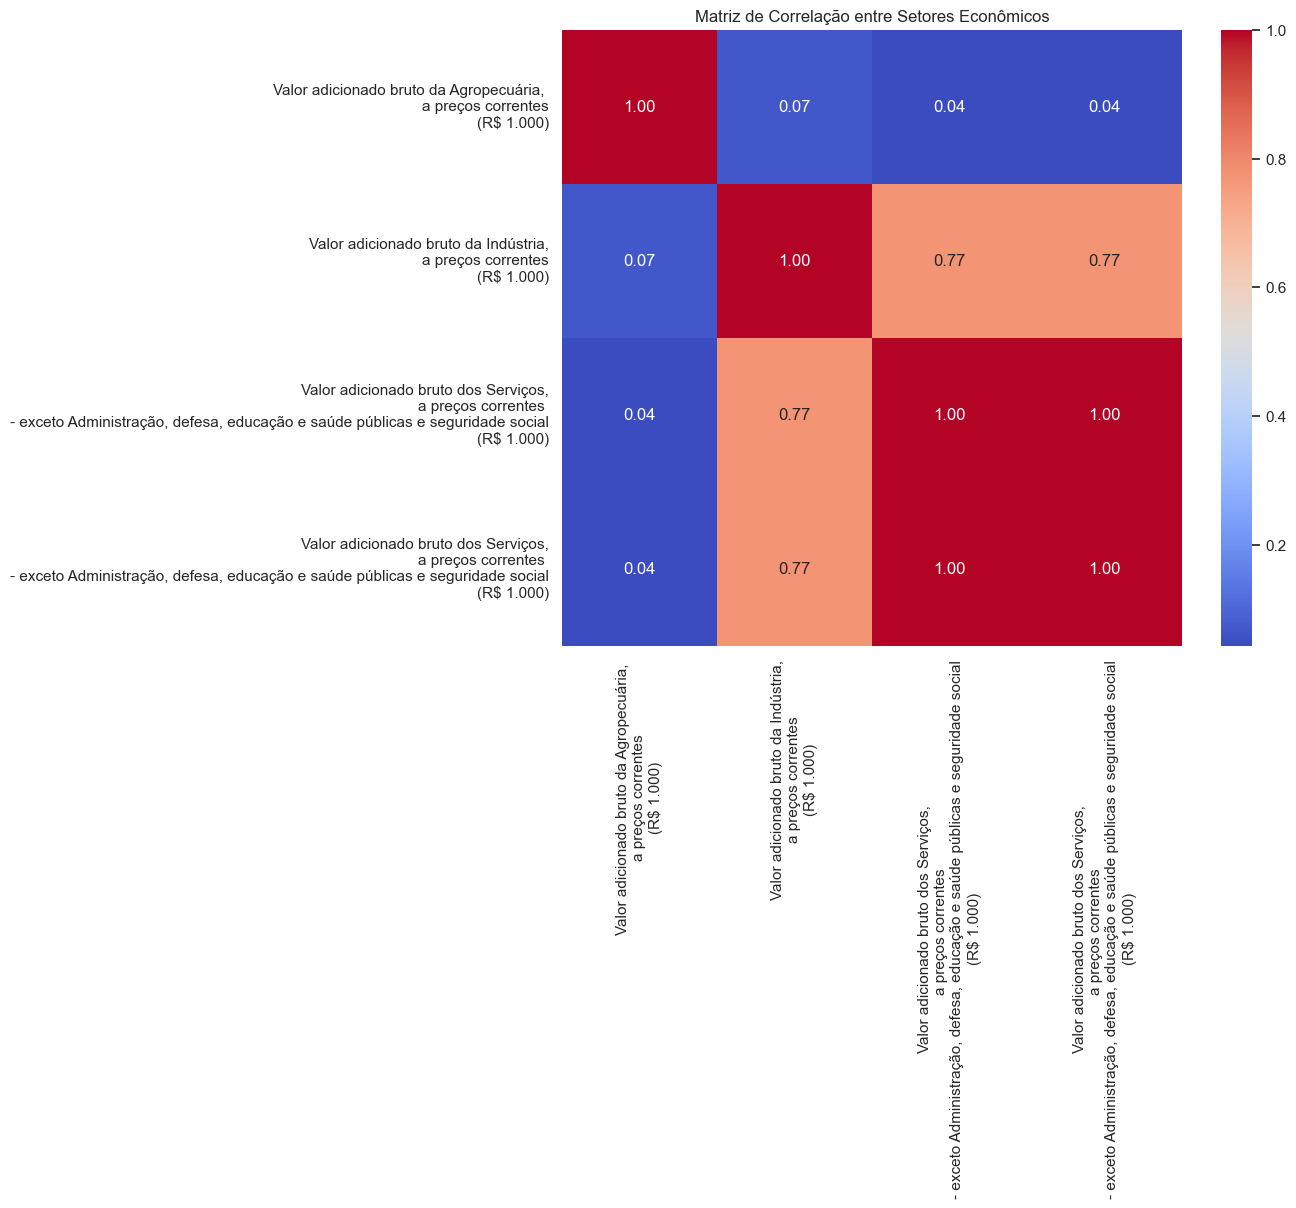

Colunas identificadas e correlação calculada com sucesso.


In [5]:
def encontrar_coluna(termo):
    return [c for c in df.columns if termo in c][0]

try:
    col_agro = encontrar_coluna('Agropecuária')
    col_ind = encontrar_coluna('Indústria')
    col_serv = encontrar_coluna('Serviços')
    col_adm = encontrar_coluna('Administração')

    cols_quant = [col_agro, col_ind, col_serv, col_adm]
    
    # 3.1 Matriz de Correlação
    corr_matrix = df[cols_quant].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Matriz de Correlação entre Setores Econômicos')
    plt.show()

    print("Colunas identificadas e correlação calculada com sucesso.")
except IndexError:
    print("Erro: Não foi possível localizar as colunas. Verifique df.columns.")

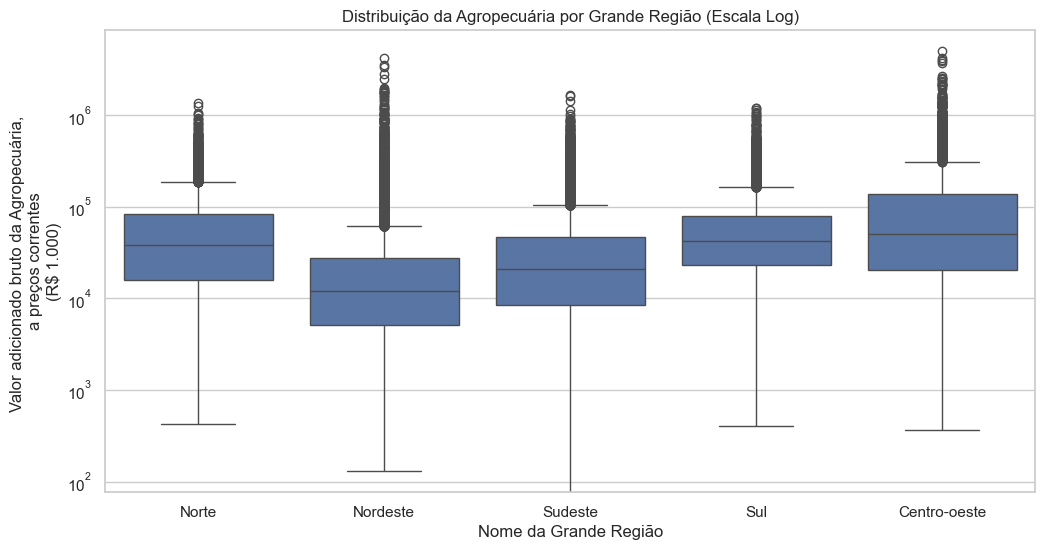

In [6]:
# 3.2 Relação Quantitativa vs Qualitativa
# Analisando o Valor da Agropecuária por Região
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Nome da Grande Região', y=col_agro)
plt.yscale('log') # Escala logarítmica devido aos outliers identificados na Parte 1
plt.title('Distribuição da Agropecuária por Grande Região (Escala Log)')
plt.show()

## 4. Conclusão da Análise Exploratória
Os resultados acima fornecem o "retrato fiel" exigido. Identificamos as regiões de maior 
influência e as variáveis que possuem maior correlação com o valor bruto da agropecuária, 
preparando o terreno para a modelagem de regressão no próximo notebook.